<a href="https://colab.research.google.com/github/marvinjc/proyecto_final_CD/blob/main/cd_final_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto final: Aguas superficiales CONAGUA 2020
Limpieza, EDA, preparación (Pipeline) y K-means geográfico

Flujo OSEMN: Obtain → Scrub → Explore → Model → Interpret.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,FunctionTransformer

sns.set_theme(style="whitegrid")
RUTA_SITIOS = "/content/sample_data/Datos_de_calidad_del_agua_de_sitios_de_monitoreo_de_aguas_superficiales_2020.csv"
RUTA_ESCALAS = "/content/sample_data/Escalas_superficial.csv"

## 1. Carga e inspección inicial

OSEMN Obtain: se carga el CSV CONAGUA 2020 y se revisa forma, tipos y muestra.

In [ ]:
df_crudo = pd.read_csv(RUTA_SITIOS, encoding="latin-1")

In [ ]:
df_crudo.shape

(4141, 55)

In [ ]:
df_crudo.columns

Index(['CLAVE', 'SITIO', 'ORGANISMO_DE_CUENCA', 'ESTADO', 'MUNICIPIO',
       'CUENCA', 'CUERPO DE AGUA', 'TIPO', 'SUBTIPO', 'LONGITUD', 'LATITUD',
       'PERIODO', 'DBO_mg/L', 'CALIDAD_DBO', 'DQO_mg/L', 'CALIDAD_DQO',
       'SST_mg/L', 'CALIDAD_SST', 'COLI_FEC_NMP_100mL', 'CALIDAD_COLI_FEC',
       'E_COLI_NMP_100mL', 'CALIDAD_E_COLI', 'ENTEROC_NMP_100mL',
       'CALIDAD_ENTEROC', 'OD_PORC', 'CALIDAD_OD_PORC', 'OD_PORC_SUP',
       'CALIDAD_OD_PORC_SUP', 'OD_PORC_MED', 'CALIDAD_OD_PORC_MED',
       'OD_PORC_FON', 'CALIDAD_OD_PORC_FON', 'TOX_D_48_UT', 'CALIDAD_TOX_D_48',
       'TOX_V_15_UT', 'CALIDAD_TOX_V_15', 'TOX_D_48_SUP_UT',
       'CALIDAD TOX_D_48_SUP', 'TOX_D_48_FON_UT', 'CALIDAD_TOX_D_48_FON',
       'TOX_FIS_SUP_15_UT', 'CALIDAD_TOX_FIS_SUP_15', 'TOX_FIS_FON_15_UT',
       'CALIDAD_TOX_FIS_FON_15', 'SEMAFORO', 'CONTAMINANTES', 'CUMPLE_CON_DBO',
       'CUMPLE_CON_DQO', 'CUMPLE_CON_SST', 'CUMPLE_CON_CF',
       'CUMPLE_CON_E_COLI', 'CUMPLE_CON_ENTEROC', 'CUMPLE_CON_OD',
  

In [ ]:
df_crudo.dtypes

,0
CLAVE,object
SITIO,object
ORGANISMO_DE_CUENCA,object
ESTADO,object
MUNICIPIO,object
CUENCA,object
CUERPO DE AGUA,object
TIPO,object
SUBTIPO,object
LONGITUD,float64


In [ ]:
df_crudo.head()

,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,...,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
0,DLAGU8,PRESA EL SAUCILLO 100M AGUAS ARRIBA DE LA CORTINA,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,RINCON DE ROMOS,RIO SAN PEDRO,PRESA EL SAUCILLO,LENTICO,PRESA,-102.33911,...,"DQO,CF,",SI,NO,SI,NO,SI,ND,SI,SI,LENTICO
1,DLBAJ100,"LOS CABOS SEG 22, 2 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN JOSE DEL CABO,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.84290,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
2,DLBAJ101,"LOS CABOS SEG 22, 1 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.86442,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
3,DLBAJ102,LOS CABOS 3,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.88604,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
4,DLBAJ103,LOS CABOS 1,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.89657,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO


In [ ]:
df_crudo.sample(5, random_state=42)

,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,...,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
2083,OCGCE3239,FELIPE CARRILLO PUERTO,GOLFO CENTRO,VERACRUZ DE IGNACIO DE LA LLAVE,MARTINEZ DE LA TORRE,RIO NAUTLA,RIO BOBOS,LOTICO (HUMEDAL),RIO,-96.95467,...,"CF,E_COLI,",SI,SI,SI,NO,NO,ND,SI,SI,LOTICO
1965,OCFSU3124,"PUERTO MADERO SEG 73, 3 ISA8",FRONTERA SUR,CHIAPAS,TAPACHULA,PUERTO MADERO,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-92.41338,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
1582,DLTAB5561,MANATI 10,FRONTERA SUR,TABASCO,MACUSPANA,Chilapa,NaN,LOTICO,NaN,-92.30760,...,"CF,",SI,SI,SI,NO,SI,ND,ND,SI,LOTICO
296,DLDUR676M1,PRESA SANTIAGO BAYACORA,PACIFICO NORTE,DURANGO,DURANGO,RIO SANTIAGO BAYACORA,PRESA SANTIAGO BAYACORA,LENTICO (HUMEDAL),PRESA,-104.67751,...,NaN,SI,SI,SI,SI,SI,ND,SI,SI,LENTICO
149,DLCHI294,PLANTA NORTE,RIO BRAVO,CHIHUAHUA,JUAREZ,RIO BRAVO 1,CANAL,LOTICO,CANAL,-106.37040,...,NaN,SI,SI,SI,SI,SI,ND,SI,SI,LOTICO


In [ ]:
print(df_crudo.shape)
df_crudo.info(verbose=True, show_counts=True)

(4141, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4141 entries, 0 to 4140
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLAVE                   3493 non-null   object 
 1   SITIO                   3493 non-null   object 
 2   ORGANISMO_DE_CUENCA     3493 non-null   object 
 3   ESTADO                  3493 non-null   object 
 4   MUNICIPIO               3493 non-null   object 
 5   CUENCA                  3492 non-null   object 
 6   CUERPO DE AGUA          3479 non-null   object 
 7   TIPO                    3493 non-null   object 
 8   SUBTIPO                 3479 non-null   object 
 9   LONGITUD                3493 non-null   float64
 10  LATITUD                 3493 non-null   float64
 11  PERIODO                 3493 non-null   float64
 12  DBO_mg/L                2581 non-null   object 
 13  CALIDAD_DBO             2581 non-null   object 
 14  DQO_mg/L                2581 

In [ ]:
import os
if os.path.exists(RUTA_ESCALAS):
    escalas = pd.read_csv(RUTA_ESCALAS, encoding="latin-1")
    display(escalas.head(12))
else:
    print("Escalas_superficial.csv no disponible localmente; las escalas están en las columnas CALIDAD_* del CSV")

,CALIDAD DEL AGUA PARA TOXICIDAD,CRITERIO,DESCRIPCION
0,No t¢xico,TOX menor a 1,Agua no contaminada.Toxicidad no detectable.
1,Toxicidad baja,TOX mayor o igual a 1 y menor o igual a 1.33,Toxicidad baja
2,Toxicidad moderada,TOX mayor de 1.33 y menor a 5,Toxicidad moderada
3,Toxicidad alta,TOX mayor o igual a 5,Toxicidad alta
4,CALIDAD DEL AGUA PARA SST,CRITERIO,DESCRIPCION
5,Excelente,SST menor o igual a 25,"Clase de excepci¢n, muy buena calidad."
6,Buena calidad,SST mayor de 25 y menor o igual a 75,Aguas superficiales con bajo contenido de soli...
7,Aceptable,SST mayor de 75 y menor o igual a 150,Aguas superficiales con indicio de contaminaci...
8,Contaminada,SST mayor de 150 y menor o igual a 400,Aguas superficiales de mala calidad con descar...
9,Fuertemente contaminada,SST mayor de 400,Aguas superficiales con fuerte impacto de desc...


## 2. Limpieza de datos
OSEMN Scrub: `a_numero`, LD/2 y nulos por GRUPO. No se pisa el CSV.

Rúbrica 2.5: Busqueda de nulos nulos, valores mal escritos (`<10`, `ND`) y sustitución (LD/2).

- `ND` / vacio -> NaN (no se midio; no se inventa un valor).
- `<10` -> 5: convencion (límite de detección)LD/2 para datos censurados. **No es la medicion exacta**; CONAGUA solo reporta que era menor al limite. Se usa para poder hacer describe, boxplot y correlacion.
- `>100` -> 100: se usa el limite; se pierde la distincion "mayor que".
- LATITUD / LONGITUD o SEMAFORO faltante: se elimina, **no se imputa**.

In [ ]:
nulos_antes = df_crudo.isna().sum()
nulos_antes = nulos_antes[nulos_antes > 0].sort_values(ascending=False)
pd.DataFrame({
    "nulos": nulos_antes,
    "porcentaje": (nulos_antes / len(df_crudo) * 100).round(1),
})

,nulos,porcentaje
TOX_FIS_FON_15_UT,4141,100.0
CALIDAD_TOX_FIS_FON_15,4141,100.0
TOX_D_48_FON_UT,4141,100.0
CALIDAD_TOX_D_48_FON,4141,100.0
OD_PORC_MED,3654,88.2
CALIDAD_OD_PORC_MED,3654,88.2
CALIDAD TOX_D_48_SUP,3379,81.6
TOX_D_48_SUP_UT,3379,81.6
ENTEROC_NMP_100mL,3237,78.2
CALIDAD_ENTEROC,3237,78.2


In [ ]:
Y = "SEMAFORO"
COLS_GEO = ["LONGITUD", "LATITUD"]
COLORES_SEMAFORO = {"Verde": "#2e7d32", "Amarillo": "#c98d00", "Rojo": "#c62828"}

COLS_LAB = [
    "DBO_mg/L", "DQO_mg/L", "SST_mg/L",
    "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL", "ENTEROC_NMP_100mL",
    "OD_PORC", "OD_PORC_SUP", "OD_PORC_MED", "OD_PORC_FON",
    "TOX_D_48_UT", "TOX_V_15_UT", "TOX_D_48_SUP_UT", "TOX_FIS_SUP_15_UT",
]

X_NUMERICAS = [
    "DBO_mg/L", "DQO_mg/L", "SST_mg/L",
    "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL", "ENTEROC_NMP_100mL",
    "OD_PORC", "OD_PORC_SUP",
]

def a_numero(valor):
    """'54.08' -> 54.08 | '<10' -> 5 (LD/2, convencion) | '>100' -> 100 | ND/vacio -> NaN"""
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip()
    if texto == "" or texto.upper() == "ND":
        return np.nan
    texto = texto.replace(",", "")
    if texto.startswith("<"):
        try:
            return float(texto[1:]) / 2.0
        except ValueError:
            return np.nan
    if texto.startswith(">"):
        try:
            return float(texto[1:])
        except ValueError:
            return np.nan
    try:
        return float(texto)
    except ValueError:
        return np.nan

In [ ]:
df = df_crudo.dropna(subset=["CLAVE"]).copy()
df["CLAVE"] = df["CLAVE"].astype(str).str.strip()
df = df[df["CLAVE"] != ""].copy()

for col in COLS_LAB + COLS_GEO:
    if col in df.columns:
        df[col] = df[col].map(a_numero)

df[Y] = df[Y].astype(str).str.strip().str.title()
df.loc[df[Y].isin(["Nan", "Nd", "None", ""]), Y] = np.nan

if "GRUPO" in df.columns:
    df["GRUPO"] = df["GRUPO"].astype(str).str.strip().str.upper()

n0 = len(df)
df = df.dropna(subset=COLS_GEO).copy()
print("Eliminadas por lat/lon faltante:", n0 - len(df))

n1 = len(df)
df = df.dropna(subset=[Y]).copy()
print("Eliminadas por SEMAFORO faltante:", n1 - len(df))
print("Sitios listos:", len(df))
df[COLS_LAB[:5] + COLS_GEO + [Y]].head()

Eliminadas por lat/lon faltante: 0
Eliminadas por SEMAFORO faltante: 0
Sitios listos: 3493


,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,LONGITUD,LATITUD,SEMAFORO
0,6.0,54.08,13.7500,1162.0,98.0,-102.33911,22.24730,Rojo
1,NaN,NaN,5.0000,NaN,NaN,-109.84290,22.90473,Verde
2,NaN,NaN,5.0000,NaN,NaN,-109.86442,22.89880,Verde
3,NaN,NaN,13.9667,NaN,NaN,-109.88604,22.89609,Verde
4,NaN,NaN,5.0000,NaN,NaN,-109.89657,22.87694,Verde


In [ ]:
nulos_despues = df.isna().sum()
nulos_despues = nulos_despues[nulos_despues > 0].sort_values(ascending=False)
pd.DataFrame({
    "nulos": nulos_despues,
    "porcentaje": (nulos_despues / len(df) * 100).round(1),
})

,nulos,porcentaje
TOX_FIS_FON_15_UT,3493,100.0
CALIDAD_TOX_FIS_FON_15,3493,100.0
CALIDAD_TOX_D_48_FON,3493,100.0
TOX_D_48_FON_UT,3493,100.0
OD_PORC_MED,3006,86.1
CALIDAD_OD_PORC_MED,3006,86.1
TOX_D_48_SUP_UT,2731,78.2
CALIDAD TOX_D_48_SUP,2731,78.2
CALIDAD_ENTEROC,2589,74.1
ENTEROC_NMP_100mL,2589,74.1


### Nulos por GRUPO
Comprobar si un parametro no se midio en COSTERO / LOTICO / LENTICO **antes** de afirmarlo.

In [ ]:
nulos_grupo = (
    df.groupby("GRUPO")[X_NUMERICAS]
    .agg(lambda serie: serie.isna().mean() * 100)
    .round(1)
)
nulos_grupo

,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,ENTEROC_NMP_100mL,OD_PORC,OD_PORC_SUP
GRUPO,,,,,,,,
COSTERO,91.3,91.3,0.1,91.3,91.3,9.4,94.8,9.0
LENTICO,1.0,1.0,0.0,0.8,0.8,99.2,100.0,2.2
LOTICO,0.2,0.2,0.2,0.2,0.2,99.8,1.5,99.8


# 5. K-means: calidad vs ubicacion geografica
OSEMN Model.

In [ ]:
from pathlib import Path

import folium
from scipy.stats import chi2_contingency
from sklearn.metrics import silhouette_samples
from shapely.geometry import MultiPoint

SEMILLA = 42
ORDEN_SEMAFORO = ["Verde", "Amarillo", "Rojo"]
COLORES_CLUSTER = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
AZUL, TINTA = "#2a78d6", "#0b0b0b"
# Opcional: geojson con los estados para dibujar el contorno de México en el mapa estático.
RUTA_ESTADOS = "/content/sample_data/datos_geo/mexico_estados.geojson"
RUTA_SALIDAS = Path("salidas"); RUTA_SALIDAS.mkdir(exist_ok=True)

X = df[COLS_GEO].to_numpy()
df["SEMAFORO_NUM"] = df[Y].map({"Verde": 0, "Amarillo": 1, "Rojo": 2})
print(X.shape, "| nulos:", np.isnan(X).sum())

(3493, 2) | nulos: 0


In [ ]:
valores_k = range(2, 13)
inercia, silueta = [], []
for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X)
    inercia.append(modelo.inertia_)
    silueta.append(silhouette_score(X, modelo.labels_))
eleccion_k = pd.DataFrame({"inercia": inercia, "silhouette": silueta}, index=pd.Index(valores_k, name="k")).round(3)

# Codo: punto más alejado de la recta que une el primer y el último valor de inercia (ambos ejes normalizados a [0, 1]).
x_n = (np.array(valores_k) - valores_k[0]) / (valores_k[-1] - valores_k[0])
y_n = (np.array(inercia) - inercia[-1]) / (inercia[0] - inercia[-1])
K_CODO = int(valores_k[np.argmax((1 - x_n) - y_n)])
print("Codo de la inercia: k =", K_CODO, "| Mejor silhouette: k =", eleccion_k["silhouette"].idxmax())
eleccion_k.T

Codo de la inercia: k = 4 | Mejor silhouette: k = 2


k,2,3,4,5,6,7,8,9,10,11,12
inercia,86050.400,47179.937,35198.214,27563.492,20416.876,15702.252,13391.277,11562.657,9990.603,8994.157,8237.535
silhouette,0.503,0.465,0.410,0.447,0.461,0.470,0.447,0.436,0.425,0.420,0.428


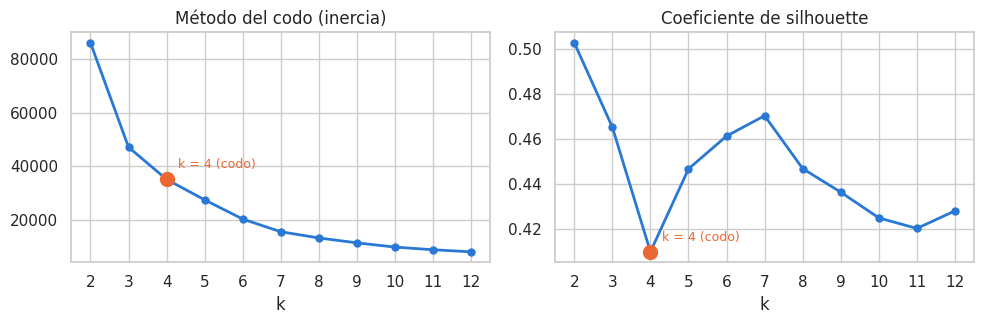

In [ ]:
K = 4  # k elegido: coincide con el codo (ver texto siguiente)
fig, (eje1, eje2) = plt.subplots(1, 2, figsize=(10, 3.4))
for eje, serie, titulo in [(eje1, inercia, "Método del codo (inercia)"), (eje2, silueta, "Coeficiente de silhouette")]:
    eje.plot(list(valores_k), serie, color=AZUL, linewidth=2, marker="o", markersize=5)
    eje.plot(K, serie[K - 2], marker="o", markersize=10, color="#eb6834", zorder=3)
    eje.annotate(f"k = {K} (codo)", (K, serie[K - 2]), textcoords="offset points", xytext=(8, 8), fontsize=9, color="#eb6834")
    eje.set_title(titulo); eje.set_xlabel("k"); eje.set_xticks(list(valores_k))
fig.tight_layout()
fig.savefig(RUTA_SALIDAS / "codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=K, n_init=10, random_state=SEMILLA).fit(X)
print(f"Convergió en {kmeans.n_iter_} iteraciones | inercia = {kmeans.inertia_:,.0f} | silhouette = {silhouette_score(X, kmeans.labels_):.3f}")

# Se renumeran los clusters de oeste a este para que el número tenga un significado estable.
orden = np.argsort(kmeans.cluster_centers_[:, 0])
nuevo_numero = {viejo: nuevo + 1 for nuevo, viejo in enumerate(orden)}
df["CLUSTER"] = pd.Series(kmeans.labels_, index=df.index).map(nuevo_numero)
centroides = pd.DataFrame(kmeans.cluster_centers_[orden], columns=["LONGITUD", "LATITUD"], index=pd.RangeIndex(1, K + 1, name="CLUSTER"))

NOMBRES = {1: "Noroeste", 2: "Occidente-Norte", 3: "Centro-Golfo", 4: "Sur-Península"}

# Radio medio: distancia de cada sitio a su centroide, en km (1° de latitud ≈ 111 km; 1° de longitud ≈ 111·cos(lat) km).
dif = df[COLS_GEO].to_numpy() - centroides.loc[df["CLUSTER"]].to_numpy()
df["DIST_CENTROIDE_KM"] = np.hypot(dif[:, 0] * 111 * np.cos(np.radians(df["LATITUD"])), dif[:, 1] * 111)
df["SILHOUETTE"] = silhouette_samples(X, kmeans.labels_)

resumen = centroides.round(2).assign(
    region=pd.Series(NOMBRES),
    sitios=df["CLUSTER"].value_counts().sort_index(),
    pct_sitios=df["CLUSTER"].value_counts(normalize=True).mul(100).round(1).sort_index(),
    radio_medio_km=df.groupby("CLUSTER")["DIST_CENTROIDE_KM"].mean().round(0).astype(int),
    silhouette_medio=df.groupby("CLUSTER")["SILHOUETTE"].mean().round(2),
    estados_principales=df.groupby("CLUSTER")["ESTADO"].agg(lambda s: ", ".join(s.str.title().value_counts().head(4).index)),
)
resumen

Convergió en 12 iteraciones | inercia = 35,198 | silhouette = 0.410


,LONGITUD,LATITUD,region,sitios,pct_sitios,radio_medio_km,silhouette_medio,estados_principales
CLUSTER,,,,,,,,
1,-111.54,28.33,Noroeste,428,12.3,407,0.46,"Sonora, Baja California, Baja California Sur, ..."
2,-103.46,22.42,Occidente-Norte,978,28.0,331,0.30,"Jalisco, Nayarit, Sinaloa, Nuevo Leon"
3,-98.87,19.48,Centro-Golfo,1393,39.9,246,0.42,"Veracruz De Ignacio De La Llave, Guerrero, Mic..."
4,-92.11,17.79,Sur-Península,694,19.9,283,0.50,"Chiapas, Tabasco, Quintana Roo, Oaxaca"


In [ ]:
tabla = pd.crosstab(df["CLUSTER"], df[Y])[ORDEN_SEMAFORO]
pct_cluster = tabla.div(tabla.sum(axis=1), axis=0).mul(100).round(1)
pct_cluster["indice_medio (0=verde, 2=rojo)"] = df.groupby("CLUSTER")["SEMAFORO_NUM"].mean().round(2)
pct_cluster.insert(0, "region", pd.Series(NOMBRES))
pct_cluster.insert(1, "sitios", tabla.sum(axis=1))
pct_cluster

SEMAFORO,region,sitios,Verde,Amarillo,Rojo,"indice_medio (0=verde, 2=rojo)"
CLUSTER,,,,,,
1,Noroeste,428,59.3,22.7,18.0,0.59
2,Occidente-Norte,978,26.5,43.4,30.2,1.04
3,Centro-Golfo,1393,24.6,31.7,43.8,1.19
4,Sur-Península,694,59.4,24.9,15.7,0.56


In [ ]:
def asociacion(tabla_contingencia):
    tabla_contingencia = tabla_contingencia.loc[tabla_contingencia.sum(axis=1) > 0, tabla_contingencia.sum(axis=0) > 0]
    chi2, p, gl, esperadas = chi2_contingency(tabla_contingencia)
    n = tabla_contingencia.to_numpy().sum()
    v = np.sqrt(chi2 / (n * (min(tabla_contingencia.shape) - 1)))
    return {"n": n, "chi2": round(chi2, 1), "gl": gl, "p": p, "V_de_Cramer": round(v, 3), "min_esperada": round(esperadas.min(), 1)}

pruebas = {"TODOS": asociacion(tabla)}
for grupo, parte in df.groupby("GRUPO"):
    pruebas[grupo] = asociacion(pd.crosstab(parte["CLUSTER"], parte[Y]))
pruebas = pd.DataFrame(pruebas).T
pruebas

,n,chi2,gl,p,V_de_Cramer,min_esperada
TODOS,3493.0,452.5,6.0,1.427109e-94,0.255,133.7
COSTERO,988.0,156.5,6.0,3.228938e-31,0.281,14.7
LENTICO,733.0,106.3,6.0,1.238739e-20,0.269,21.6
LOTICO,1772.0,114.3,6.0,2.614920e-22,0.180,22.3


In [ ]:
mezcla = pd.crosstab(df["CLUSTER"], df["GRUPO"], normalize="index").mul(100).round(0).astype(int).add_prefix("% ")
rojo_por_grupo = df.groupby(["CLUSTER", "GRUPO"])["SEMAFORO"].apply(lambda s: s.eq("Rojo").mean() * 100).unstack().round(0).astype(int).add_prefix("% rojo en ")
control = pd.concat([pd.Series(NOMBRES, name="region"), mezcla, rojo_por_grupo], axis=1).rename_axis("CLUSTER")
control

,region,% COSTERO,% LENTICO,% LOTICO,% rojo en COSTERO,% rojo en LENTICO,% rojo en LOTICO
CLUSTER,,,,,,,
1,Noroeste,45,19,36,5,14,36
2,Occidente-Norte,18,28,54,18,23,38
3,Centro-Golfo,22,22,57,34,55,43
4,Sur-Península,45,12,43,7,34,19


In [ ]:
principales = ["DBO_mg/L", "DQO_mg/L", "SST_mg/L", "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL", "OD_PORC"]
medianas_cluster = df.groupby("CLUSTER")[principales].median().round(1)
medianas_cluster.insert(0, "region", pd.Series(NOMBRES))
medianas_cluster["n_con_DBO"] = df.groupby("CLUSTER")["DBO_mg/L"].count()
medianas_cluster

,region,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,OD_PORC,n_con_DBO
CLUSTER,,,,,,,,
1,Noroeste,1.0,17.7,14.9,794.0,52.0,79.6,231
2,Occidente-Norte,1.0,23.0,26.2,2909.0,257.5,89.6,830
3,Centro-Golfo,4.4,35.1,28.0,2400.0,1100.0,57.3,1121
4,Sur-Península,2.8,26.1,24.0,750.0,230.0,61.3,399


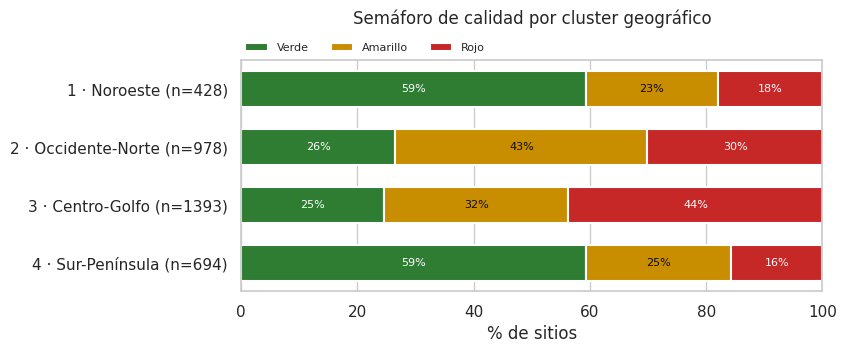

In [ ]:
def barras_semaforo(eje, porcentajes, titulo):
    izquierda = np.zeros(len(porcentajes))
    for color in ORDEN_SEMAFORO:
        valores = porcentajes[color].to_numpy()
        eje.barh(porcentajes.index.astype(str), valores, left=izquierda, height=0.62,
                 color=COLORES_SEMAFORO[color], edgecolor="white", linewidth=1.5, label=color)
        for y, (x0, v) in enumerate(zip(izquierda, valores)):
            if v >= 7:
                eje.text(x0 + v / 2, y, f"{v:.0f}%", ha="center", va="center", fontsize=8,
                         color="white" if color != "Amarillo" else TINTA)
        izquierda += valores
    eje.set_xlim(0, 100); eje.invert_yaxis(); eje.grid(axis="y", visible=False)
    eje.set_xlabel("% de sitios"); eje.set_title(titulo, pad=26)
    eje.legend(ncols=3, loc="lower left", bbox_to_anchor=(-0.01, 0.99), frameon=False, fontsize=8)

fig, eje = plt.subplots(figsize=(7.5, 3))
etiquetas_cluster = pct_cluster.apply(lambda f: f"{f.name} · {f['region']} (n={f['sitios']})", axis=1)
barras_semaforo(eje, pct_cluster[ORDEN_SEMAFORO].set_axis(etiquetas_cluster), "Semáforo de calidad por cluster geográfico")
fig.savefig(RUTA_SALIDAS / "semaforo_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

# 6. Visualización: mapa de México
OSEMN Interpret

Rúbrica 2: agrupamiento lat/lon en el mapa de México (este gráfico).

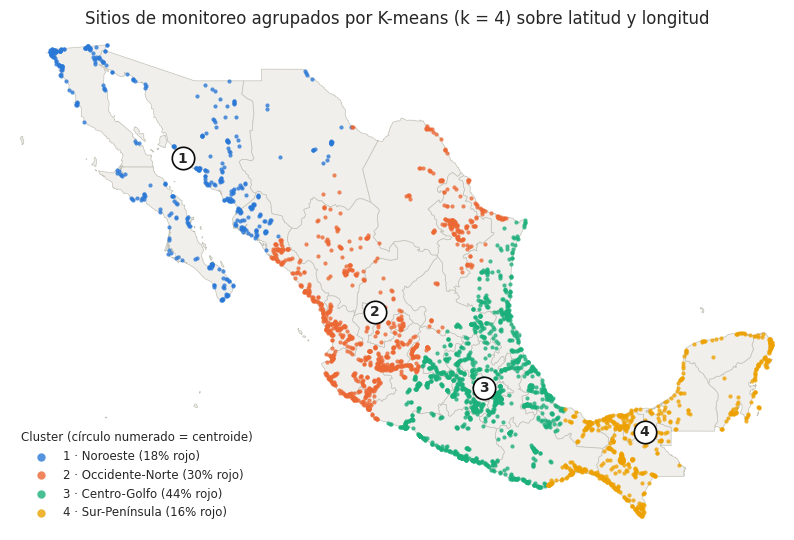

In [ ]:
fig, eje = plt.subplots(figsize=(10, 6.6))
if Path(RUTA_ESTADOS).exists():
    import geopandas as gpd
    gpd.read_file(RUTA_ESTADOS).plot(ax=eje, facecolor="#f0efec", edgecolor="#c3c2b7", linewidth=0.5)
eje.set_xlim(-118.8, -86.2); eje.set_ylim(14, 33.2); eje.set_aspect(1 / np.cos(np.radians(23.5)))
eje.set_axis_off(); eje.set_title(f"Sitios de monitoreo agrupados por K-means (k = {K}) sobre latitud y longitud")
for numero in range(1, K + 1):
    parte = df[df["CLUSTER"] == numero]
    eje.scatter(parte["LONGITUD"], parte["LATITUD"], s=9, color=COLORES_CLUSTER[numero - 1], alpha=0.8,
                linewidths=0, label=f"{numero} · {NOMBRES[numero]} ({pct_cluster.loc[numero, 'Rojo']:.0f}% rojo)")
eje.scatter(centroides["LONGITUD"], centroides["LATITUD"], s=260, color="white", edgecolor=TINTA, linewidth=1.2, zorder=4)
for numero, c in centroides.iterrows():
    eje.text(c["LONGITUD"], c["LATITUD"], str(numero), ha="center", va="center", fontsize=10, fontweight="bold", zorder=5)
eje.legend(title="Cluster (círculo numerado = centroide)", loc="lower left", frameon=False, fontsize=8.5, title_fontsize=8.5, markerscale=2)
fig.savefig(RUTA_SALIDAS / "mapa_kmeans_mexico.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
mapa = folium.Map(location=[23.6, -102.5], zoom_start=5, tiles="CartoDB positron", prefer_canvas=True)
capa_regiones = folium.FeatureGroup(name="Regiones K-means (envolvente de cada cluster)").add_to(mapa)
capa_sitios = folium.FeatureGroup(name="Sitios (color = semáforo)").add_to(mapa)
for numero in range(1, K + 1):
    parte = df[df["CLUSTER"] == numero]
    envolvente = MultiPoint(parte[COLS_GEO].to_numpy()).convex_hull
    folium.Polygon([(lat, lon) for lon, lat in envolvente.exterior.coords], color=COLORES_CLUSTER[numero - 1], weight=2,
                   fill=True, fill_opacity=0.12, tooltip=f"Cluster {numero} · {NOMBRES[numero]}").add_to(capa_regiones)
for fila in df.itertuples():
    folium.CircleMarker([fila.LATITUD, fila.LONGITUD], radius=3, weight=0, fill=True, fill_opacity=0.85,
                        fill_color=COLORES_SEMAFORO[fila.SEMAFORO],
                        tooltip=f"{str(fila.SITIO).title()} · cluster {fila.CLUSTER} · {fila.SEMAFORO}").add_to(capa_sitios)
for numero, c in centroides.iterrows():
    folium.Marker(
        [c["LATITUD"], c["LONGITUD"]],
        tooltip=f"Centroide {numero} · {NOMBRES[numero]}: {pct_cluster.loc[numero, 'Verde']:.0f}% verde, "
                f"{pct_cluster.loc[numero, 'Amarillo']:.0f}% amarillo, {pct_cluster.loc[numero, 'Rojo']:.0f}% rojo",
        icon=folium.DivIcon(html=f'<div style="width:24px;height:24px;border-radius:50%;background:#fff;border:2px solid #0b0b0b;'
                                 f'text-align:center;line-height:20px;font-weight:bold;font-size:12px;margin:-6px 0 0 -6px">{numero}</div>'),
    ).add_to(mapa)
folium.LayerControl(collapsed=False).add_to(mapa)
mapa.save(RUTA_SALIDAS / "/content/sample_data/salidas/mapa_interactivo_kmeans.html")
mapa

In [ ]:
rojos = df[Y].eq("Rojo")
for clusters, nombre in [([3], "Centro-Golfo"), ([2, 3], "Occidente-Norte + Centro-Golfo")]:
    en = df["CLUSTER"].isin(clusters)
    print(f"{nombre}: {en.mean():.0%} de los sitios y {rojos[en].sum() / rojos.sum():.0%} de los semáforos rojos del país")

Centro-Golfo: 40% de los sitios y 56% de los semáforos rojos del país
Occidente-Norte + Centro-Golfo: 68% de los sitios y 83% de los semáforos rojos del país


## 7. Conclusiones
OSEMN Interpret: ¿la calidad sigue la ubicación?

Rúbrica 1: hallazgos del EDA y de K-means (calidad vs ubicación).

1. **Limpieza.** Las mediciones venian como texto (`<10`, `ND`). Se convirtieron con la convencion LD/2 (no es la medicion exacta; permite el EDA). Se eliminaron filas sin CLAVE, sin coordenadas o sin semaforo. Lat/lon no se imputaron. Los nulos que quedan se comprobaron por GRUPO (celda de % nulos): COSTERO casi no tiene DBO; LOTICO/LENTICO casi no tienen enterococos.

2. **EDA.** Varias variables tienen media mayor que la mediana (sesgo positivo), sobre todo bacteriologia y materia organica. Los boxplots muestran outliers. Hay correlacion fuerte DBO-DQO y coliformes-E. coli. Lat/lon casi no correlacionan con las mediciones.

3. **K-means.**

4. **Mapas.**